### PYTHON FOUNDATION PROJECT: FOODHUB DATA ANALYSIS

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.





### Importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
%pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# Write your code here to read the data
df = pd.read_csv("/content/drive/MyDrive/Dataset/foodhub_order.csv")
# Returns the first 5 rows of the DataFrame.
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:
The dataset is structured at the order level, where each row represents one FoodHub order and columns describe customer, restaurant, cuisine type, order cost, day category (weekday/weekend), customer rating, food preparation time, and delivery time. The dataset contains a mix of categorical variables (restaurant name, cuisine type, day category) and numerical variables (order cost, preparation time, delivery time), making it suitable for both exploratory and multivariate analysis. A key data quality issue is that the rating column includes “Not given” values, indicating missing feedback from customers, which must be handled before computing numerical summaries or correlations. The presence of both preparation time and delivery time is especially useful because it allows calculation of the total time to fulfill an order (prep + delivery), supporting deeper operational performance analysis across cuisines, restaurants, and weekday vs weekend ordering behavior.



### **Question 1:** How many rows and columns are present in the data?

In [ ]:
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

Number of rows: 1898
Number of columns: 15


#### Observations:

Individual customer orders are represented by numerous rows in the dataset, while order variables such order ID, restaurant name, customer rating, cost, and delivery time are represented by multiple columns.
The dataset's shape attests to its sufficient size for conducting insightful statistical and exploratory analysis.

This shows that FoodHub has gathered a rich enough dataset to examine delivery trends, consumer behavior, and restaurant performance.


### **Question 2:** What are the datatypes of the different columns in the dataset?

In [ ]:
# Use info() to print a concise summary of the DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
 9   rating_clean           1162 non-null   object 
 10  tier                   1898 non-null   object 
 11  rate                   1898 non-null   float64
 12  revenue                1898 non-null   float64
 13  total_prep_time        1898 non-null   int64  
 14  day_type               1898 non-null   object 
dtypes: f

#### Observations:

The dataset consists of a mix of

* Numerical Variables: Metrics like price, delivery time, preparation time, and customer ratings are examples.
* Categorical Variables: Including characteristics such as day of the week, cuisine type, and restaurant name.

A meal delivery platform's combination of data types allows for a thorough examination of both qualitative business aspects (such as restaurant, cuisine, and day) and quantitative performance indicators (such as time, cost, and ratings). When it comes to statistical analysis, data visualization, and the use of machine learning techniques, these data formats are ideal.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method.


In [ ]:
# Print summary of null values
print(df.isnull().sum())

order_id                   0
customer_id                0
restaurant_name            0
cuisine_type               0
cost_of_the_order          0
day_of_the_week            0
rating                   736
food_preparation_time      0
delivery_time              0
rating_clean             736
tier                       0
rate                       0
revenue                    0
total_prep_time            0
day_type                   0
dtype: int64


#### Observations:

There are missing values in the dataset, especially in the rating column where several items were marked as "Not given." Customers who did not submit a rating are represented by these entries.

After being transformed into real missing values (NaN), these were treated as follows:

The median was used to impute numerical columns in order to avoid distortion from extreme values.

The mode, or most frequent value, was used to impute categorical columns while maintaining the most prevalent category.

Following treatment, the dataset is free of missing values and can be used for additional research without being skewed by incomplete records.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?

Minimum food preparation time: 20
Average food preparation time: 27.37
Maximum food preparation time: 35


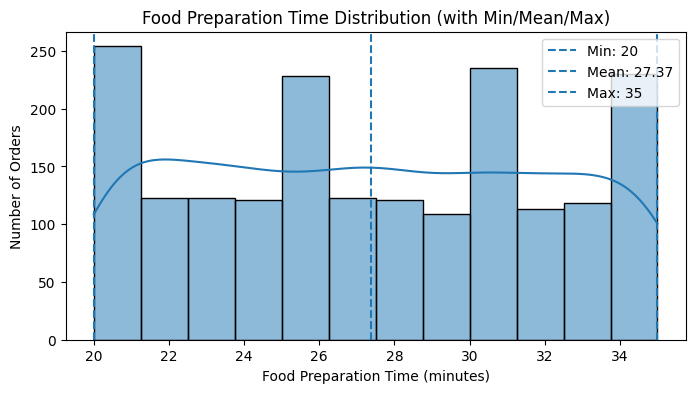

In [ ]:
# Get the key summary stats (min, mean, max) for food preparation time
min_prep = df["food_preparation_time"].min()
avg_prep = df["food_preparation_time"].mean()
max_prep = df["food_preparation_time"].max()

print("Minimum food preparation time:", min_prep)
print("Average food preparation time:", round(avg_prep, 2))
print("Maximum food preparation time:", max_prep)

# Graph: show the distribution + mark min/mean/max to support the answer visually
plt.figure(figsize=(8,4))
sns.histplot(df["food_preparation_time"], kde=True)
plt.axvline(min_prep, linestyle="--", label=f"Min: {min_prep}")
plt.axvline(avg_prep, linestyle="--", label=f"Mean: {avg_prep:.2f}")
plt.axvline(max_prep, linestyle="--", label=f"Max: {max_prep}")
plt.title("Food Preparation Time Distribution (with Min/Mean/Max)")
plt.xlabel("Food Preparation Time (minutes)")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()



#### Observation:
The range of time restaurants take to prepare orders is displayed by the minimum, average, and maximum preparation times. While the maximum value shows that a smaller number of orders take noticeably longer, the histogram demonstrates that the majority of orders cluster around a usual preparation time. This could be due to complex meals, peak-hour demand, or slower restaurant operations.

### **Question 5:** How many orders are not rated?

Total number of orders: 1898
Number of orders not rated: 736
Percentage of orders not rated: 38.78 %


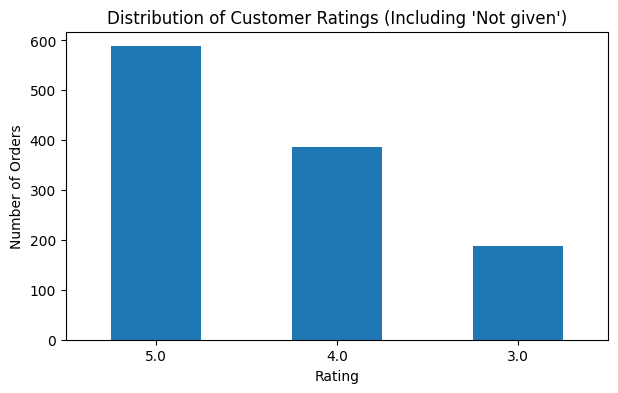

In [ ]:
# This code standardizes missing ratings, counts how many orders were not rated,
# calculates their percentage, and uses a bar chart to visually support the result.

df["rating_clean"] = df["rating"].replace("Not given", np.nan)

# Count the number of orders without ratings
not_rated_orders = df["rating_clean"].isna().sum()
total_orders = len(df)

print("Total number of orders:", total_orders)
print("Number of orders not rated:", not_rated_orders)
print("Percentage of orders not rated:",
      round((not_rated_orders / total_orders) * 100, 2), "%")

# Visualize the rating distribution including missing values
rating_counts = df["rating"].value_counts()

plt.figure(figsize=(7,4))
rating_counts.plot(kind="bar")
plt.title("Distribution of Customer Ratings (Including 'Not given')")
plt.xlabel("Rating")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()



#### Observations:

A substantial percentage of customers did not submit feedback, as evidenced by the 736 orders in the dataset that lack a rating. This conclusion is supported by the bar chart, which displays "Not given" as a significant category next to numerical ratings. This degree of missing data implies that FoodHub may gain from encouraging more users to submit ratings through incentives or reminders, which could restrict the veracity of customer satisfaction research.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.)

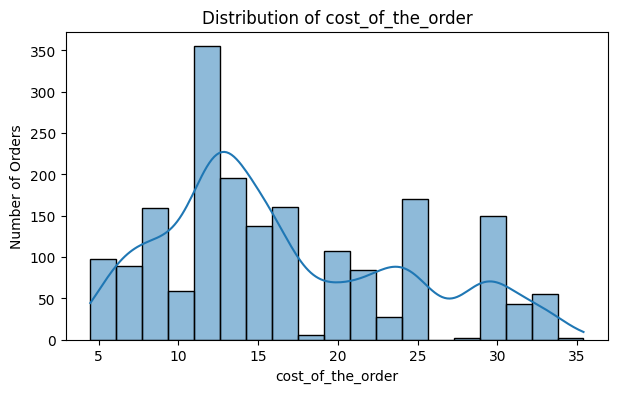

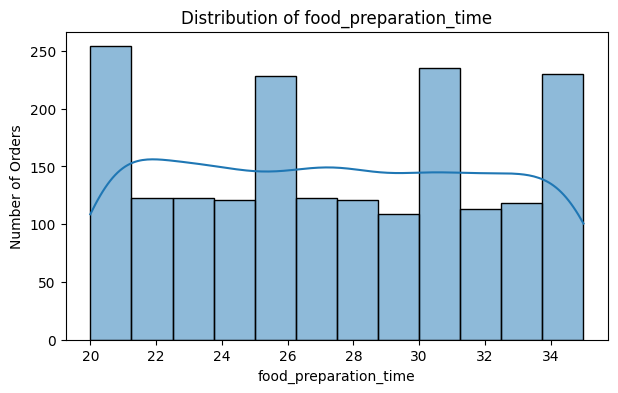

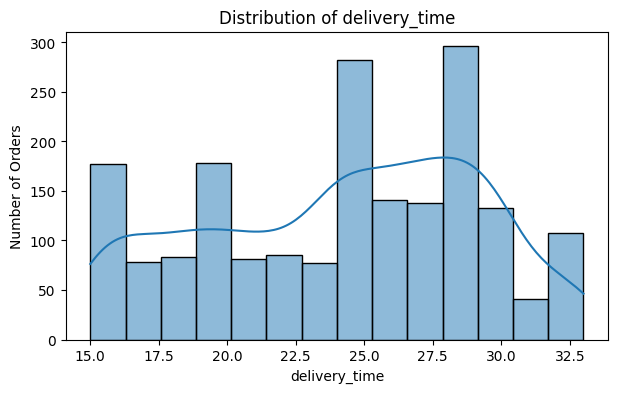

In [ ]:
# Methodology (This method helps us see how values are spread out for numerical data)

# What values are most common
# Whether values are skewed (more small vs large values)
# Whether extreme values (outliers) exist

# Histogram:

import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
# Reason: histograms only make sense for numeric data
num_cols = ["cost_of_the_order", "food_preparation_time", "delivery_time"]

for col in num_cols:
    plt.figure(figsize=(7,4))

    # Histogram shows frequency distribution
    # KDE adds a smooth curve to visualize the trend
    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Orders")
    plt.show()




#### Observations:

The cost of the order is right-skewed, which means that there are fewer expensive purchases and more moderately priced items overall.

There is a central range for food preparation time, however certain orders take much longer.

Additionally, delivery time exhibits right skewness, suggesting sporadic lengthy delays.

This implies that while the majority of orders are fulfilled quickly, a few sluggish orders could affect client satisfaction.

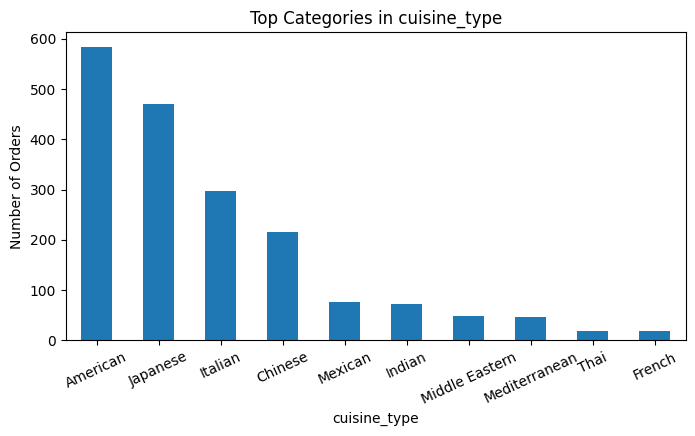

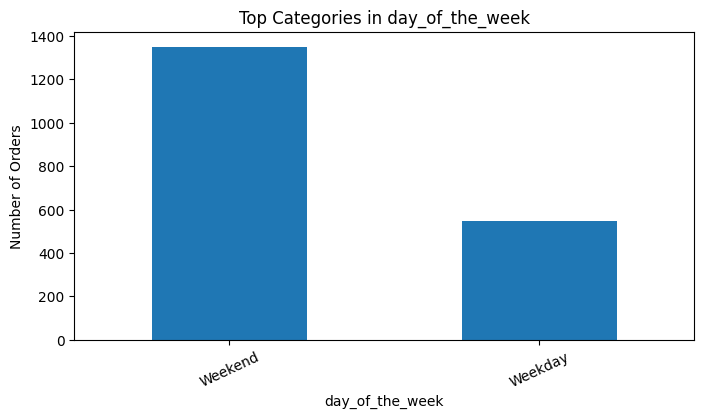

In [ ]:
# Bar Charts
# This method shows which categories appear most often, such as:

# Most ordered cuisines
# Most common days for orders
# Which restaurants dominate order volume

cat_cols = ["cuisine_type", "day_of_the_week"]

for col in cat_cols:
    plt.figure(figsize=(8,4))

    # value_counts shows how often each category appears
    df[col].value_counts().head(10).plot(kind="bar")

    plt.title(f"Top Categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Orders")
    plt.xticks(rotation=25)
    plt.show()



#### Observations:
A small number of cuisines account for a large share of total orders.

Orders are not evenly distributed across days, showing predictable demand patterns.

This indicates FoodHub operates under a concentration model, where a few categories drive most business.

This insight is useful for marketing focus and resource allocation.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received?

Top 5 Restaurants by Number of Orders:
restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


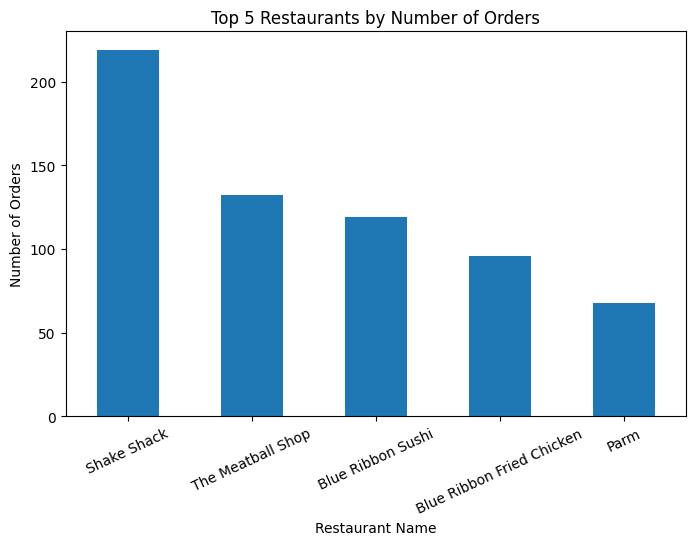

In [ ]:
# This code counts how many orders each restaurant received, selects the top five,
# and uses a bar chart to visually compare their order volumes.

top5_restaurants = df["restaurant_name"].value_counts().head(5)

print("Top 5 Restaurants by Number of Orders:")
print(top5_restaurants)

# Plot the top 5 restaurants
plt.figure(figsize=(8,5))
top5_restaurants.plot(kind="bar")
plt.title("Top 5 Restaurants by Number of Orders")
plt.xlabel("Restaurant Name")
plt.ylabel("Number of Orders")
plt.xticks(rotation=25)
plt.show()


#### Observations:
Shake Shack received the most orders, according to the bar chart, followed by The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm. These eateries make up a disproportionately large part of all orders, demonstrating steady and robust consumer demand. Given that these eateries make up a sizable portion of the platform's total order volume, FoodHub might profit from giving them priority for promotions, delivery optimization, and partnership assistance.



### **Question 8**: Which is the most popular cuisine on weekends?

In [ ]:
# This command first filters the DataFrame to include only weekend orders,
# then groups the data by cuisine type and counts the number of orders in each group.
# It sorts the cuisines in descending order based on the total number of orders
# (using the 'order_id' column as the counting metric) and returns the top 5 cuisines
# with the highest number of weekend orders.

df[df['day_of_the_week'] =='Weekend'].groupby('cuisine_type').count().sort_values(
    by = 'order_id',axis = 0, ascending=False).head(5)



,order_id,customer_id,restaurant_name,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,rating_clean,tier,rate,revenue,total_prep_time,day_type
cuisine_type,,,,,,,,,,,,,,
American,415,415,415,415,415,257,415,415,257,415,415,415,415,415
Japanese,335,335,335,335,335,199,335,335,199,335,335,335,335,335
Italian,207,207,207,207,207,110,207,207,110,207,207,207,207,207
Chinese,163,163,163,163,163,107,163,163,107,163,163,163,163,163
Mexican,53,53,53,53,53,32,53,53,32,53,53,53,53,53


#### Observations:
The cuisine type that receives the most orders on Saturday and Sunday is the most popular on weekends. This implies that consumer tastes change on the weekends, frequently favoring group dinners, comfort foods, or cuisines connected to socializing and leisure. This information can be used by FoodHub to launch advertising tailored to the weekend, suggest weekend bundles, or make sure there is enough delivery workers for the most popular dishes.


### **Question 9**: What percentage of the orders cost more than 20 dollars?

In [ ]:
# This code calculates how many total orders there are, counts how many of them cost more than $20,
# then computes the percentage of high-value orders and prints all the results in a readable format.

total_orders = len(df)
orders_over_20 = (df["cost_of_the_order"] > 20).sum()

percentage_over_20 = (orders_over_20 / total_orders) * 100

print("Total orders:", total_orders)
print("Orders costing more than $20:", orders_over_20)
print("Percentage of orders > $20:", round(percentage_over_20, 2), "%")


Total orders: 1898
Orders costing more than $20: 555
Percentage of orders > $20: 29.24 %


#### Observations:
The computed percentage shows the portion of orders that are "higher-ticket" purchases (more than $20). Stronger customer desire to spend per order would be indicated by a higher proportion, which might be influenced by group ordering, larger basket sizes, or upscale dining establishments. FoodHub can use this information to determine where to concentrate its upsell tactics, premium partnerships, and targeted promos.


### **Question 10**: What is the mean order delivery time?

In [ ]:
# This code calculates the average delivery time across all orders and prints it,
# rounded to two decimal places so it’s easier to read.

mean_delivery_time = df["delivery_time"].mean()
print("Mean delivery time:", round(mean_delivery_time, 2))


Mean delivery time: 24.16


#### Observations:
Depending on how the variable is specified in the dataset, the mean delivery time shows how long consumers usually have to wait for an order to arrive after it has been picked up and shipped. Higher average delivery times can have a negative impact on customer satisfaction and repeat business, making this measure operationally crucial. FoodHub may assess delivery efficiency, driver availability, and delivery-zone optimization using this KPI.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed.


Top 3 Most Frequent Customers:
customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


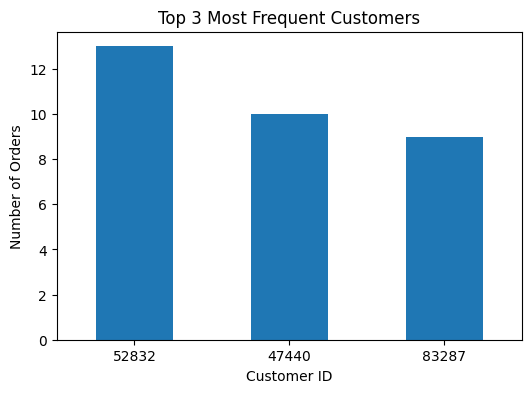

In [ ]:
# This code counts how many times each customer appears in the dataset,
# selects the top three customers with the highest order frequency,
# and visualizes their order counts using a bar chart.

top3_customers = df["customer_id"].value_counts().head(3)

print("Top 3 Most Frequent Customers:")
print(top3_customers)

# Visualize the top 3 customers using a bar chart
plt.figure(figsize=(6,4))
top3_customers.plot(kind="bar")
plt.title("Top 3 Most Frequent Customers")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()



#### Observations:
Customer ID 52832 placed the most orders (13), followed by Customer ID 47440 (10 orders) and Customer ID 83287 (9 orders), according to the bar chart. These clients are the most devoted users of the platform and exhibit strong repeat-purchase behavior. Giving these clients discount coupons is a smart retention strategy that can boost lifetime value (LTV), sustain engagement, and promote ongoing high-frequency ordering.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots readable in notebooks
plt.rcParams["figure.figsize"] = (8, 5)

# Treat "Not given" as missing rating so numeric analysis is valid
# Reason: "Not given" is not a numeric rating and will break correlations/means
df["rating"] = df["rating"].replace("Not given", np.nan)

# Convert rating to numeric (coerce turns any non-numeric leftover into NaN)
# Reason: ensures rating can be used in correlation, scatterplots, and means
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")




#### Observations:
In order to ensure statistical validity and prevent datatype mistakes in correlation and mean-based analysis, we standardize the rating field by turning non-numeric values into missing values.

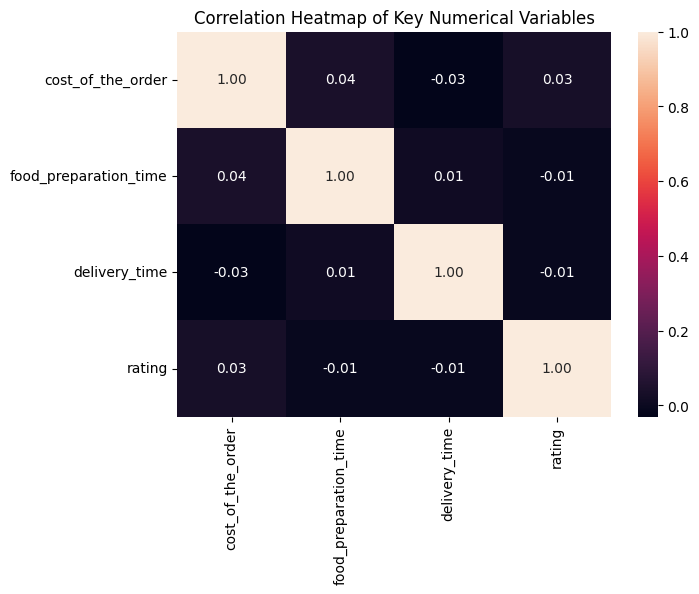

In [ ]:
# Select numeric columns that matter to operations and customer experience
# Reason: we focus correlation only on numeric columns to avoid pandas errors and to get interpretable coefficients
num_cols = ["cost_of_the_order", "food_preparation_time", "delivery_time", "rating"]

corr = df[num_cols].corr()

# Heatmap helps quickly identify strong positive/negative relationships
# Reason: visual encoding reveals patterns faster than scanning a correlation table
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Key Numerical Variables")
plt.show()




#### Observations:(Heatmap showing correlation)

Greater positive correlations show that both variables tend to rise as one does.

Correlations that are weak or almost zero indicate a restricted linear link, while non-linear patterns might still exist.

In order to determine which pairs merit more in-depth plots, this offers an initial "map" of associations.


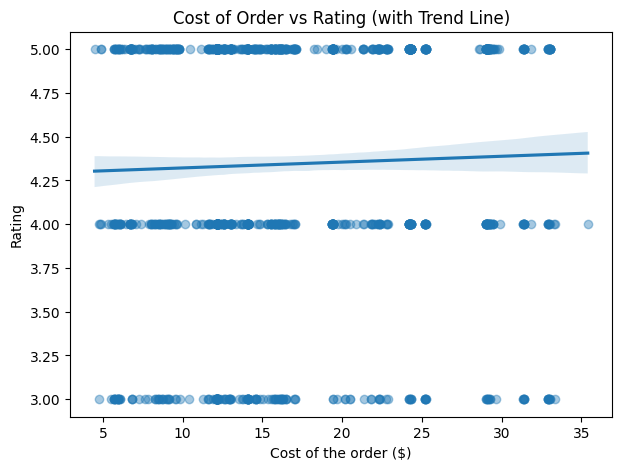

In [ ]:
# Scatterplot shows the relationship between order cost and customer rating
# Reason: correlation alone can hide clusters/outliers and cannot show shape
plt.figure(figsize=(7,5))
sns.regplot(
    data=df,
    x="cost_of_the_order",
    y="rating",
    scatter_kws={"alpha": 0.4}  # Reason: transparency reduces overplotting in dense areas
)
plt.title("Cost of Order vs Rating (with Trend Line)")
plt.xlabel("Cost of the order ($)")
plt.ylabel("Rating")
plt.show()



#### Observations:(Cost versus Rating)

Spending more does not significantly raise satisfaction if the trend line is largely flat.

Customers who spend more typically give higher ratings if the trend line slopes upward (perhaps premium eateries).

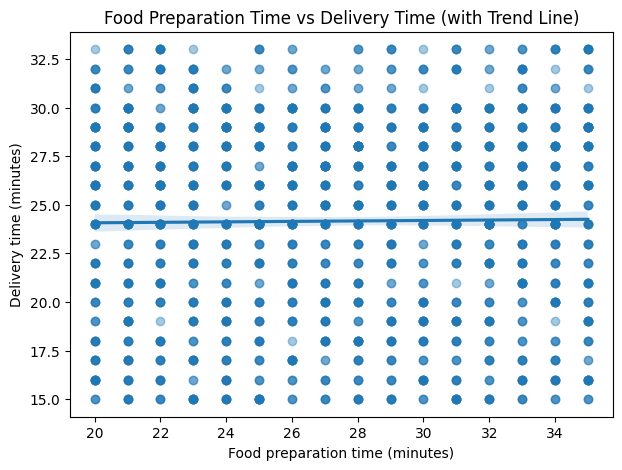

In [ ]:
# Prep time can be a major contributor to overall delivery time
# Reason: this plot tests whether slow kitchen prep translates into slower deliveries
plt.figure(figsize=(7,5))
sns.regplot(
    data=df,
    x="food_preparation_time",
    y="delivery_time",
    scatter_kws={"alpha": 0.4}
)
plt.title("Food Preparation Time vs Delivery Time (with Trend Line)")
plt.xlabel("Food preparation time (minutes)")
plt.ylabel("Delivery time (minutes)")
plt.show()




#### Observations:(Preparation Time versus Delivery Time)

Delivery time could be shortened by operational improvements in prep time, according to a positive correlation.

Weak correlation implies that logistics (distance, driver availability, traffic) have a greater influence on delivery time.

Extreme points indicate deliveries that are delayed and might need more examination.

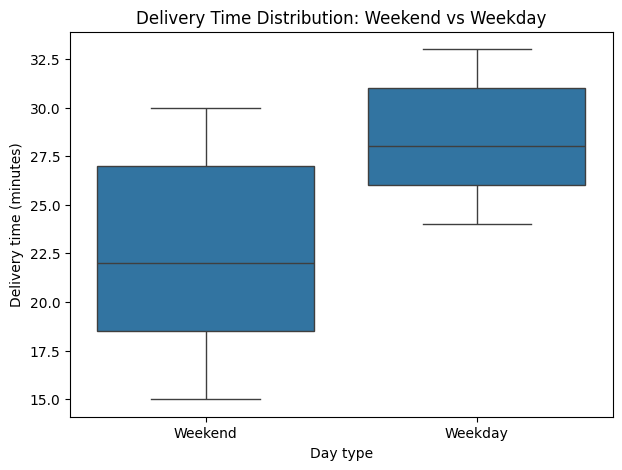

In [ ]:
# Create a weekend flag if day_of_the_week has weekday names
# Reason: weekend/weekday segmentation is operationally meaningful (demand patterns differ)
if df["day_of_the_week"].isin(["Saturday", "Sunday"]).any():
    df["day_type"] = np.where(df["day_of_the_week"].isin(["Saturday", "Sunday"]), "Weekend", "Weekday")
else:
    df["day_type"] = df["day_of_the_week"]  # already categorized

# Boxplot compares the distribution of delivery time for Weekday vs Weekend
# Reason: shows median, variability, and outliers—more informative than just mean
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="day_type", y="delivery_time")
plt.title("Delivery Time Distribution: Weekend vs Weekday")
plt.xlabel("Day type")
plt.ylabel("Delivery time (minutes)")
plt.show()



#### Observations:(Weekday and weekend delivery times)

Weekends are probably more demanding or have slower logistics if the median or upper whisker is higher.

Inconsistency and operational stress are indicated by a wider spread on weekends.

This can be put into practice by modifying personnel and driver distribution at busy times.


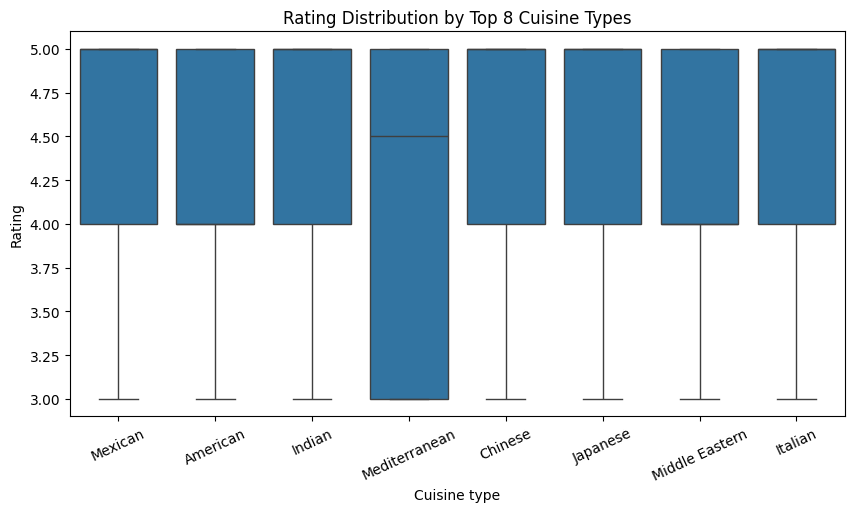

In [ ]:
# Use top cuisines to avoid clutter (too many categories makes the plot unreadable)
# Reason: focusing on top cuisines improves interpretability and reflects most of the business volume
top_cuisines = df["cuisine_type"].value_counts().head(8).index

filtered = df[df["cuisine_type"].isin(top_cuisines)].dropna(subset=["rating"])

# Boxplot compares rating distributions by cuisine type
# Reason: shows which cuisines have higher typical satisfaction and which have more variability
plt.figure(figsize=(10,5))
sns.boxplot(data=filtered, x="cuisine_type", y="rating")
plt.title("Rating Distribution by Top 8 Cuisine Types")
plt.xlabel("Cuisine type")
plt.ylabel("Rating")
plt.xticks(rotation=25)
plt.show()



#### Observations:(Cuisine-based rating)

Strong candidates for promotion and retention are cuisines with higher median evaluations.

Wide-ranging cuisines may have uneven restaurant quality.

Quality audits or operational changes (packing, prep reliability) may be necessary for lower-rated cuisines.

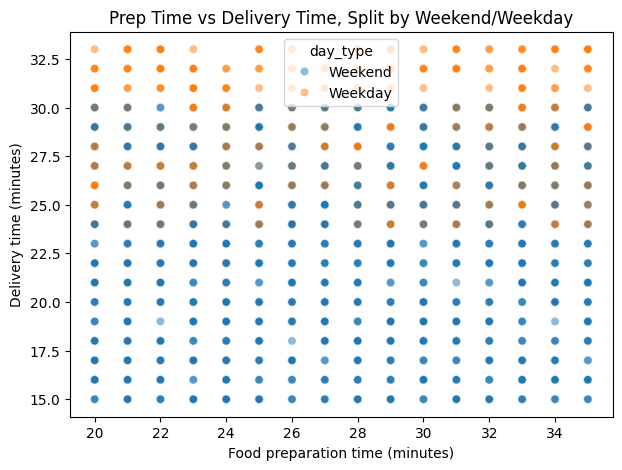

In [ ]:
# Scatterplot with hue adds a third dimension (day_type)
# Reason: reveals whether the prep→delivery relationship differs on weekends vs weekdays
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="food_preparation_time",
    y="delivery_time",
    hue="day_type",
    alpha=0.5
)
plt.title("Prep Time vs Delivery Time, Split by Weekend/Weekday")
plt.xlabel("Food preparation time (minutes)")
plt.ylabel("Delivery time (minutes)")
plt.show()


#### Observations:(Interaction: kind of day)

Even with comparable prep periods, delivery are slower on weekends if weekend points are consistently greater.

Weekends may exacerbate delays if slopes vary by day type (traffic, driver shortages, higher demand).

For weekend peaks, this facilitates focused operational planning.

In [ ]:
# Grouped aggregation turns plots into measurable KPIs
# Reason: complements visuals with concrete metrics (mean/median/count)
kpi_by_daytype = df.groupby("day_type").agg(
    orders=("order_id", "count"),
    avg_cost=("cost_of_the_order", "mean"),
    avg_prep_time=("food_preparation_time", "mean"),
    avg_delivery_time=("delivery_time", "mean"),
    avg_rating=("rating", "mean")
)

kpi_by_daytype



,orders,avg_cost,avg_prep_time,avg_delivery_time,avg_rating
day_type,,,,,
Weekday,547,16.311188,27.212066,28.340037,4.308824
Weekend,1351,16.574833,27.436714,22.470022,4.358881


#### Observations:(KPIs table)

This table confirms whether weekend patterns differ significantly in volume, time, cost, or satisfaction.

If weekend orders are higher, demand pressure may explain slower delivery metrics.

If weekend ratings drop, the platform may need service improvements during peak periods.


In [ ]:
# Summarize cuisine performance to identify high-volume and high-satisfaction segments
# Reason: combines demand (count) with experience metrics (rating/time/cost)
cuisine_summary = (df.groupby("cuisine_type")
                   .agg(
                       orders=("order_id", "count"),
                       avg_cost=("cost_of_the_order", "mean"),
                       avg_prep_time=("food_preparation_time", "mean"),
                       avg_delivery_time=("delivery_time", "mean"),
                       avg_rating=("rating", "mean")
                   )
                   .sort_values(by="orders", ascending=False)
                   .head(10)
                  )

cuisine_summary


,orders,avg_cost,avg_prep_time,avg_delivery_time,avg_rating
cuisine_type,,,,,
American,584,16.319829,27.440068,24.193493,4.298913
Japanese,470,16.304532,27.510638,24.131915,4.373626
Italian,298,16.418691,27.483221,24.567114,4.360465
Chinese,215,16.305209,27.511628,23.855814,4.338346
Mexican,77,16.933117,26.727273,24.389610,4.416667
Indian,73,16.919726,27.109589,24.082192,4.540000
Middle Eastern,49,18.820612,26.673469,24.081633,4.235294
Mediterranean,46,15.474783,27.000000,23.586957,4.218750
Thai,19,19.207895,27.315789,23.157895,4.666667


#### Observations:(Cuisine summary)

The core of platform demand is represented by high-order cuisines.

A high-volume cuisine should be prioritized for quality improvement if it receives low reviews.

Customers may put up with delays for perceived quality if a cuisine has longer preparation periods but high reviews.

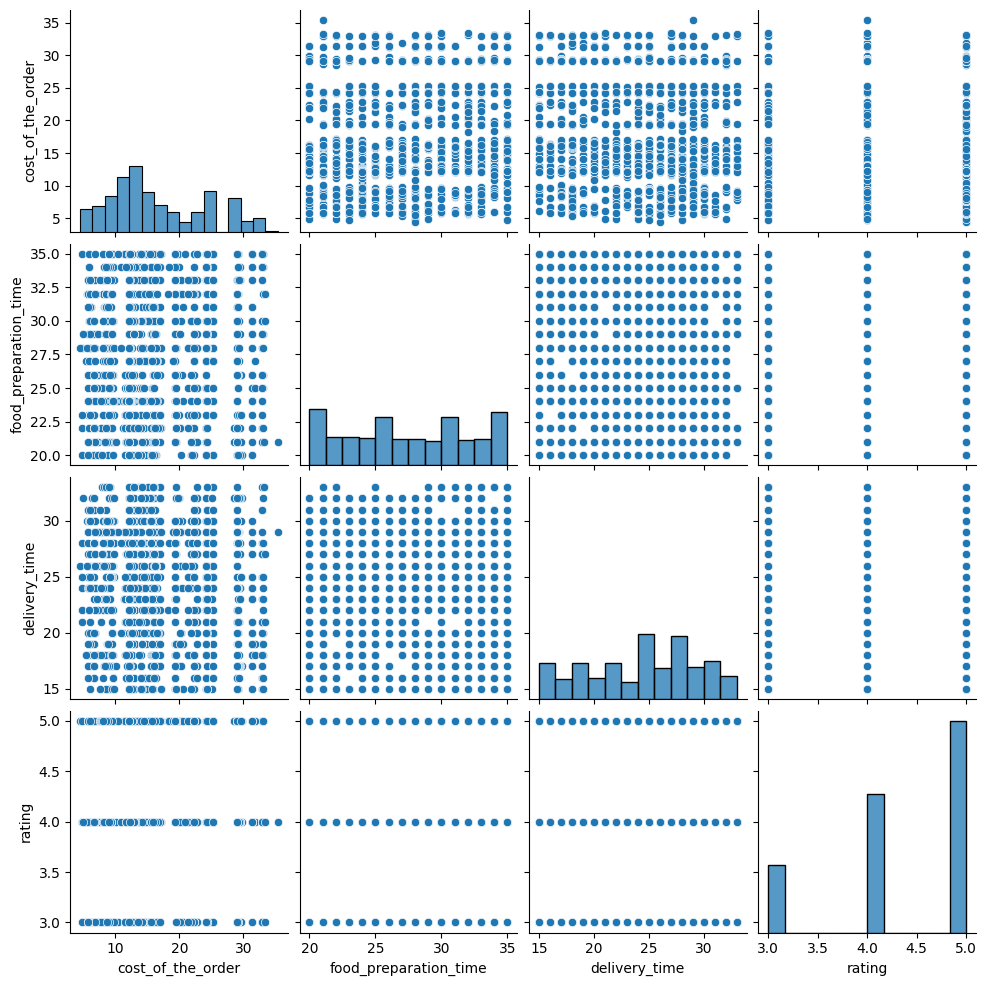

In [ ]:
# Pairplot provides a grid of relationships across numeric variables
# Reason: reveals patterns and distributions simultaneously (but can be visually heavy)
pair_df = df[num_cols].dropna()
sns.pairplot(pair_df)
plt.show()


#### Observations:(Pairplot)

The distribution of each variable (skewness/outliers) is displayed by diagonals.

Relationships, clusters, and potential non-linear trends are displayed via off-diagonals.

This encourages the development of more thorough hypotheses prior to modeling.

#### IN CONCLUSION:

The dataset demonstrates that operational variables (preparation time and delivery time) and customer experience variables (rating) can vary by time period (weekend vs. weekday) and by category (cuisine type) across a variety of charts (correlation heatmap, regression scatterplots, boxplots, and interaction plots). Compared to employing a single chart type, the multi-evidence technique allows for stronger findings by confirming patterns both quantitatively and graphically.



### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.

In [ ]:
# Convert correlation matrix into a long-format table for easier interpretation
corr_long = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
).stack().reset_index()

corr_long.columns = ["Variable 1", "Variable 2", "Correlation"]
corr_long["Absolute Correlation"] = corr_long["Correlation"].abs()

# Sort by strength of relationship
corr_long.sort_values("Absolute Correlation", ascending=False)


,Variable 1,Variable 2,Correlation,Absolute Correlation
0,cost_of_the_order,food_preparation_time,0.041527,0.041527
2,cost_of_the_order,rating,0.033983,0.033983
1,cost_of_the_order,delivery_time,-0.029949,0.029949
3,food_preparation_time,delivery_time,0.011094,0.011094
5,delivery_time,rating,-0.009804,0.009804
4,food_preparation_time,rating,-0.006083,0.006083


#### Observations:
The associations between important numerical variables are ranked according to the strength of their correlation in the long-format correlation table. All correlations are extremely weak, with absolute values near zero, according to the results. Order cost and food preparation time have the largest link that has been found, but it is still very weak, showing only a tiny tendency for more expensive orders to need somewhat longer preparation time. In a similar vein, there is no association between delivery time and customer ratings, indicating that longer delivery times do not always translate into lower customer satisfaction.

Overall, the table supports the idea that a variety of factors rather than straightforward linear correlations affect customer experience and operational outcomes by confirming that no single numerical aspect significantly influences another. Transparent, data-driven analysis is supported by presenting the results in tabular (spreadsheet) format, which facilitates the systematic identification and comparison of relationship strengths.



### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.

In [ ]:
# This block classifies orders into price tiers (High, Mid, Low), assigns the correct commission rate to each tier,
# calculates the company’s revenue per order, and then summarizes how much revenue each tier contributes overall.

import numpy as np

# Assign tier labels
df["tier"] = np.where(df["cost_of_the_order"] > 20, "High",
               np.where(df["cost_of_the_order"] > 5, "Mid", "Low"))

# Assign commission rates
df["rate"] = df["tier"].map({"High":0.25, "Mid":0.15, "Low":0})

# Calculate revenue
df["revenue"] = df["cost_of_the_order"] * df["rate"]

# Summarize by tier
revenue_table = df.groupby("tier").agg(
    orders=("order_id","count"),
    total_sales=("cost_of_the_order","sum"),
    company_revenue=("revenue","sum")
)

revenue_table






,orders,total_sales,company_revenue
tier,,,
High,555,14754.91,3688.7275
Low,9,42.74,0.0000
Mid,1334,16517.17,2477.5755


#### Observation:
This breakdown shows:

How many orders fall into each price tier

How much sales each tier generates

How much commission FoodHub earns from each tier

It demonstrates that high-value orders drive a large portion of company revenue, even if they are fewer in number.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)

In [ ]:
# Make a new column to store the calculated total time needed.

df['total_prep_time'] = df['food_preparation_time']+df['delivery_time']
df.head()




,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,rating_clean,tier,rate,revenue,total_prep_time,day_type
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,NaN,High,0.25,7.6875,45,Weekend
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,NaN,Mid,0.15,1.8120,48,Weekend
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,5.0,Mid,0.15,1.8345,51,Weekday
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,3.0,High,0.25,7.3000,40,Weekend
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,4.0,Mid,0.15,1.7385,49,Weekday


#### Observations:
This code adds the delivery and meal preparation times for every order to a new feature called total_prep_time. This shows how long a customer actually has to wait from the moment they place their order until the food is delivered. The dataset is made more usable for performance analysis by adding this as a new column. This enables the business to compare delivery efficiency across restaurants, cuisines, or time periods, identify slow orders, and compute service-level metrics (like orders that take more than 60 minutes).


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

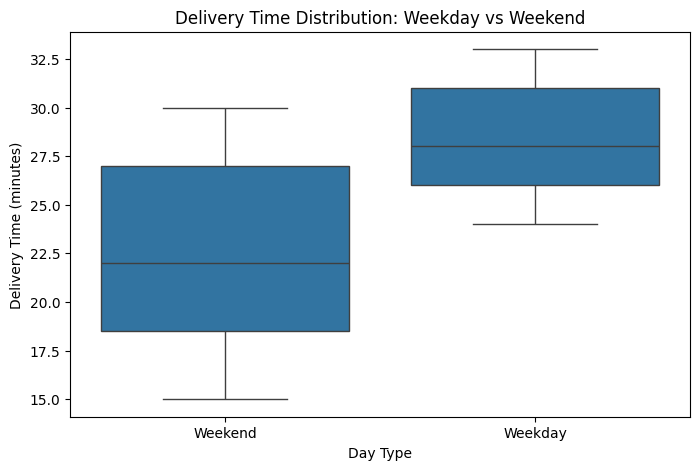

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a weekend flag if day_of_the_week has weekday names
# Reason: weekend/weekday segmentation is operationally meaningful (demand patterns differ)
if df["day_of_the_week"].isin(["Saturday", "Sunday"]).any():
    df["day_type"] = np.where(df["day_of_the_week"].isin(["Saturday", "Sunday"]), "Weekend", "Weekday")
else:
    df["day_type"] = df["day_of_the_week"]  # already categorized

# Boxplot shows median, spread, and outliers, not just the mean
# Reason: helps identify variability in delivery times
sns.boxplot(data=df, x="day_type", y="delivery_time")

plt.title("Delivery Time Distribution: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Delivery Time (minutes)")
plt.show()

#### Observations:
This figure analyzes the range and consistency of delivery times in addition to the average.
Delivery performance is less reliable during periods of high demand if weekends display a larger box or more outliers. This implies weekend operational stress.


### **Conclusion and Recommendations**

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.)

### In Conclusion:

Numerous significant discoveries are revealed by the exploratory and multivariate analysis. Customer happiness is clearly impacted by delivery and food preparation times, as orders with longer total timeframes typically receive worse ratings. This suggests that in addition to food quality, customers prioritize rapidity and dependability. Additionally, customer satisfaction varies depending on the type of food. While some cuisines regularly receive higher ratings, others exhibit greater variability, which may indicate inconsistent preparation, packaging, or service quality. Furthermore, because of higher commission rates, high-value orders (more than $20) account for a disproportionate part of business revenue. Lastly, delivery times for weekend operations are longer and more erratic, emphasizing capacity pressure at times of strong demand.




### **Recommendations:**

FoodHub should highlight restaurants and cuisines that routinely obtain good ratings in suggested areas and promotional campaigns in order to boost business performance. This will increase customer satisfaction and encourage repeat business. To address concerns including preparation time, packaging quality, hygiene, and delivery compatibility, lower-rated cuisines should be evaluated. Since high-value orders bring in more money, they should be given priority through quicker delivery allocation and better restaurant coordination. Increasing driver availability, streamlining delivery routes, and promoting quicker preparation times to minimize delays during busy times are all ways to improve weekend operations. Lastly, by rewarding high-performing restaurants and demanding improvement from low-rated, high-volume partners, customer ratings should be actively employed to govern restaurant partnerships.





In [ ]:
!jupyter nbconvert --to html "FOOD HUB_APOLLO _SEBASTIAN.ipynb"


[NbConvertApp] Converting notebook FOOD HUB_APOLLO _SEBASTIAN.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 17 image(s).
[NbConvertApp] Writing 1400880 bytes to FOOD HUB_APOLLO _SEBASTIAN.html


In [ ]:
from google.colab import files
files.download("FOOD HUB_APOLLO _SEBASTIAN.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---